# Non-Spelling SAE Absorption Testbed — Numeric & Taxonomic Hierarchies

**Demo notebook for a TEXT-ONLY dataset** built to test whether *SAE feature absorption* — a
failure mode documented almost exclusively for first-letter **spelling** features — also shows up
for two **non-spelling** parent concepts:

- **`numeric_absorption`** — parent = *"token is numeric"*; absorber sub-contexts = `year, percent,
  currency, date, decimal, integer, comma_number, ordinal`.
- **`taxonomic_absorption`** — parent = *"token is part of a country name"*; absorber sub-contexts =
  individual countries (incl. the homographs *Georgia, Turkey, Chile, Jordan*).

Each hierarchy ships three coordinated row types:
1. **content-flip minimal pairs** (`x_on` has the concept, `x_off` is a surface-matched non-concept
   word at the same slot),
2. **surface-flip pairs** (same concept token in two different carrier sentences), and
3. a **Pile diagnostic corpus** of real text windows labelled by frozen, *model-independent*
   sub-context (regex / gazetteer), with matched negatives.

> The full builder (`data.py`) streams the Pile, runs the `gemma-2-2b` tokenizer, and LLM-judges every
> generated pair — far too heavy for a quick demo. **This notebook instead loads the pre-built,
> curated subset and reproduces the dataset-composition / absorption-readiness analysis** that the
> builder writes to `manifest.json` (`pipeline.write_outputs`). The demo subset is curated from the
> **taxonomic** hierarchy only (≤100 diverse rows).

In [1]:
# --- Install dependencies (works on Colab and locally) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# This demo only uses Colab-preinstalled scientific packages.
# On Colab: skip them (use Colab's pinned versions, installing would corrupt C-extensions).
# Locally: install at Colab's EXACT versions so the env matches Colab.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports ---
import json, os
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 160)

In [3]:
# --- Data loading helper (GitHub URL with local fallback, for Colab) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-1/dataset-2/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
# --- Load the curated demo subset ---
data = load_data()
print("metadata keys:", list(data["metadata"].keys()))
print("scale:", data["metadata"].get("scale"), "| seed:", data["metadata"].get("seed"))
print("pile_revision:", data["metadata"].get("pile_revision"))
print()
for d in data["datasets"]:
    print(f"dataset {d['dataset']}: {len(d['examples'])} examples")

metadata keys: ['artifact', 'description', 'schema', 'scale', 'seed', 'pile_repo', 'pile_revision', 'gemma_tokenizer', 'token_indices_present', 'llm_model', 'llm_cost_usd', 'llm_calls', 'total_rows', 'demo_subset', 'demo_total_rows']
scale: full | seed: 20240617
pile_revision: 3be90335b66f24456a5d6659d9c8d208c0357119

dataset taxonomic_absorption: 90 examples


## Config

All tunable knobs live here. They are set to the **minimum** values that produce meaningful output
on the small curated subset. The one analysis parameter that matters for the *science* —
`READINESS_THRESHOLD` — is **150** in the full artifact; the curated subset only has a handful of
rows per sub-context, so we use a small demo threshold here.

In [5]:
# ---- Tunable demo parameters ----
# Diagnostic-fold POSITIVE rows a sub-context needs to be "eligible" for the inferential
# absorption test. FULL ARTIFACT: 150. Demo subset is tiny, so use a small threshold.
READINESS_THRESHOLD = 1          # full artifact: 150

# Display-only knobs (how many examples to print in the inspection cells).
N_CONTENT_PAIRS_SHOW = 4         # content-flip minimal pairs to print
N_SURFACE_PAIRS_SHOW = 3         # surface-flip pairs to print
N_CORPUS_ROWS_SHOW   = 5         # diagnostic corpus rows to print with spans
TOP_K_SUBCONTEXTS    = 15        # bars in the sub-context distribution plot

## 1. Flatten examples into a DataFrame

The on-disk schema (`exp_sel_data_out`) forbids nested objects inside an example, so per-row
metadata is stored as flat `metadata_<name>` keys. Here we strip the `metadata_` prefix back into
ordinary columns — one DataFrame row per data row.

In [6]:
records = []
for d in data["datasets"]:
    for ex in d["examples"]:
        rec = {"dataset": d["dataset"], "input": ex["input"], "output": ex["output"]}
        for k, v in ex.items():
            if k.startswith("metadata_"):
                rec[k[len("metadata_"):]] = v
        records.append(rec)

df = pd.DataFrame(records)
print("rows:", len(df), "| columns:", len(df.columns))
print(list(df.columns))
df[["dataset", "row_type", "output", "sub_context", "pair_role", "target_text"]].head(5)

rows: 90 | columns: 22
['dataset', 'input', 'output', 'hierarchy', 'row_type', 'concept_present', 'sub_context', 'pair_id', 'pair_role', 'target_text', 'target_char_start', 'target_char_end', 'target_token_indices', 'source', 'pile_set_name', 'llm_judge_pass', 'llm_judge_score', 'fold', 'template_id', 'neg_family', 'multi_token', 'notes']


,dataset,row_type,output,sub_context,pair_role,target_text
0,taxonomic_absorption,content_pair,positive,Portugal,x_on,Portugal
1,taxonomic_absorption,content_pair,negative,None,x_off,
2,taxonomic_absorption,content_pair,positive,Thailand,x_on,Thailand
3,taxonomic_absorption,content_pair,negative,None,x_off,
4,taxonomic_absorption,content_pair,positive,Morocco,x_on,Morocco


## 2. Dataset composition

We recompute the same summary counts that `pipeline.write_outputs` writes to `manifest.json` for the
full build: rows by `(hierarchy, row_type)`, fold counts, source counts, and the parent-label
balance. (On the curated subset these are smaller than the full artifact's 24,128 rows.)

In [7]:
print("rows_by_hierarchy_and_type:")
type_counts = Counter((r.hierarchy, r.row_type) for r in df.itertuples())
for (h, rt), n in sorted(type_counts.items()):
    print(f"  {h}/{rt}: {n}")

print("\nfold_counts:        ", dict(Counter(df["fold"])))
print("source_counts:      ", dict(Counter(df["source"])))
print("parent label (output):", dict(Counter(df["output"])))
print("pile_set_name_counts:", dict(Counter(df["pile_set_name"].dropna())))

rows_by_hierarchy_and_type:
  taxonomic/content_pair: 24
  taxonomic/corpus: 52
  taxonomic/surface_pair: 14

fold_counts:         {'train': 46, 'test': 12, 'diagnostic': 32}
source_counts:       {'templated': 38, 'pile_uncopyrighted': 52}
parent label (output): {'positive': 66, 'negative': 24}
pile_set_name_counts: {'Pile-CC': 30, 'Wikipedia (en)': 12, 'PubMed Abstracts': 5, 'FreeLaw': 1, 'HackerNews': 1, 'StackExchange': 2, 'ArXiv': 1}


## 3. Content-flip minimal pairs (`x_on` vs `x_off`)

`x_on` contains the country at the target slot; `x_off` swaps in a **surface-matched non-country
word at the same slot of the same carrier sentence**. The taxonomic hierarchy draws negatives from
country-vs-city and country-vs-other-proper-noun families (`neg_family`). These minimal pairs
isolate the parent concept from surface form.

In [8]:
cp = df[df.row_type == "content_pair"]
shown = 0
for pid, grp in cp.groupby("pair_id"):
    on = grp[grp.pair_role == "x_on"]
    off = grp[grp.pair_role == "x_off"]
    if on.empty or off.empty:
        continue
    on, off = on.iloc[0], off.iloc[0]
    print(f"pair_id={pid}  sub_context={on.sub_context}  neg_family={on.neg_family}  multi_token={on.multi_token}")
    print(f"  x_on  [{on.output}] target={on.target_text!r}: {on.input}")
    print(f"  x_off [{off.output}] target={off.target_text!r}: {off.input}")
    print()
    shown += 1
    if shown >= N_CONTENT_PAIRS_SHOW:
        break
print(f"(showing {shown} of {cp['pair_id'].nunique()} content pairs in the subset)")

pair_id=tax_cp_0000  sub_context=Portugal  neg_family=city  multi_token=False
  x_on  [positive] target='Portugal': She flew to Portugal for the summit.
  x_off [negative] target='': She flew to Mumbai for the summit.

pair_id=tax_cp_0001  sub_context=Portugal  neg_family=city  multi_token=False
  x_on  [positive] target='Portugal': She wrote her thesis on the history of Portugal.
  x_off [negative] target='': She wrote her thesis on the history of Zurich.

pair_id=tax_cp_0002  sub_context=Portugal  neg_family=city  multi_token=False
  x_on  [positive] target='Portugal': The delegation from Portugal arrived early.
  x_off [negative] target='': The delegation from Lisbon arrived early.

pair_id=tax_cp_0006  sub_context=Thailand  neg_family=city  multi_token=False
  x_on  [positive] target='Thailand': Few tourists ever travel to Thailand in winter.
  x_off [negative] target='': Few tourists ever travel to Istanbul in winter.

(showing 4 of 12 content pairs in the subset)


## 4. Surface-flip pairs (`surface_a` vs `surface_b`)

The **same** country token placed in two different carrier sentences. These power the unit-level
*surface-invariance* admission check (a real parent feature should fire on the concept regardless of
the surrounding surface form).

In [9]:
sp = df[df.row_type == "surface_pair"]
shown = 0
for pid, grp in sp.groupby("pair_id"):
    a = grp[grp.pair_role == "surface_a"]
    b = grp[grp.pair_role == "surface_b"]
    if a.empty or b.empty:
        continue
    a, b = a.iloc[0], b.iloc[0]
    print(f"pair_id={pid}  sub_context={a.sub_context}  target={a.target_text!r}")
    print(f"  surface_a: {a.input}")
    print(f"  surface_b: {b.input}")
    print()
    shown += 1
    if shown >= N_SURFACE_PAIRS_SHOW:
        break
print(f"(showing {shown} of {sp['pair_id'].nunique()} surface pairs in the subset)")

pair_id=tax_sp_0000  sub_context=Finland  target='Finland'
  surface_a: Historians have long studied Finland.
  surface_b: Cars from Finland dominate the market.

pair_id=tax_sp_0003  sub_context=Iraq  target='Iraq'
  surface_a: The cuisine of Iraq is famous worldwide.
  surface_b: Many travellers dream of seeing Iraq.

pair_id=tax_sp_0006  sub_context=Vietnam  target='Vietnam'
  surface_a: Cars from Vietnam dominate the market.
  surface_b: Many travellers dream of seeing Vietnam.

(showing 3 of 7 surface pairs in the subset)


## 5. Diagnostic corpus: target spans + gemma token indices

Each corpus row is a real natural-text window from the Pile, carrying the exact target span
(`target_char_start` / `target_char_end`) and **precomputed `google/gemma-2-2b` token indices**
(the tokenizer splits numbers into individual digit tokens, so a single number can span several
tokens). We verify here that (a) token indices are present and (b) the char span actually points at
`target_text` — the same sanity invariants the builder asserts.

In [10]:
corpus = df[df.row_type == "corpus"].copy()

# token-index coverage (the full build guarantees 100%)
has_tok = corpus["target_token_indices"].apply(lambda x: isinstance(x, list) and len(x) > 0)
print(f"corpus rows: {len(corpus)} | token-index coverage: {has_tok.mean():.0%}")

# verify char spans actually slice out target_text
def span_ok(r):
    if r.target_char_start is None or r.target_char_start < 0:
        return None
    return r.input[r.target_char_start:r.target_char_end] == r.target_text
corpus["span_ok"] = [span_ok(r) for r in corpus.itertuples()]
print("char-span matches target_text:", dict(Counter(corpus["span_ok"].dropna())))

cols = ["sub_context", "output", "target_text", "target_char_start",
        "target_char_end", "target_token_indices", "pile_set_name"]
corpus[corpus.output == "positive"][cols].head(N_CORPUS_ROWS_SHOW)

corpus rows: 52 | token-index coverage: 100%
char-span matches target_text: {True: 52}


,sub_context,output,target_text,target_char_start,target_char_end,target_token_indices,pile_set_name
38,Russia,positive,Russia,165,171,[32],Pile-CC
39,Canada,positive,Canada,260,266,[59],Pile-CC
40,France,positive,France,105,111,[38],Wikipedia (en)
41,Iran,positive,Iran,4,8,[1],Pile-CC
42,India,positive,India,132,137,[20],PubMed Abstracts


## 6. Absorption readiness

Computed exactly as `pipeline.write_outputs` does for `manifest.json`: count the diagnostic-fold
**positive** corpus rows per sub-context; a sub-context becomes **`eligible`** for the inferential
parent-hole test once it clears `READINESS_THRESHOLD` (150 in the full artifact), otherwise it is
kept and flagged **`descriptive_only`**.

Crucially, these sub-context labels come purely from surface form / gazetteer — *independent of any
SAE latent or model*. So the very same labelled corpus equally supports the honest null
("absorption is spelling-specific": uniform high parent-probe recall across sub-contexts) and a
positive finding (sub-context-specific parent holes). The dataset does **not** bake in the answer.

In [11]:
diag = Counter()
for r in df.itertuples():
    if r.row_type == "corpus" and r.output == "positive" and r.fold == "diagnostic":
        diag[r.sub_context] += 1

readiness = {sub: {"diagnostic_positives": n,
                   "status": "eligible" if n >= READINESS_THRESHOLD else "descriptive_only"}
             for sub, n in sorted(diag.items(), key=lambda x: -x[1])}

read_df = pd.DataFrame([{"sub_context": k, **v} for k, v in readiness.items()])
print(f"READINESS_THRESHOLD = {READINESS_THRESHOLD}  (full artifact uses 150)")
print("eligible:", int((read_df.status == "eligible").sum()),
      "| descriptive_only:", int((read_df.status == "descriptive_only").sum()))
read_df

READINESS_THRESHOLD = 1  (full artifact uses 150)
eligible: 22 | descriptive_only: 0


,sub_context,diagnostic_positives,status
0,France,2,eligible
1,United States,2,eligible
2,Italy,2,eligible
3,Canada,1,eligible
4,Iran,1,eligible
5,Brazil,1,eligible
6,Georgia,1,eligible
7,New Zealand,1,eligible
8,Turkey,1,eligible
9,Spain,1,eligible


## 7. Visual summary

Three views of the curated subset: rows by `row_type`, the parent-label balance, and the most
frequent sub-contexts among positive corpus rows.

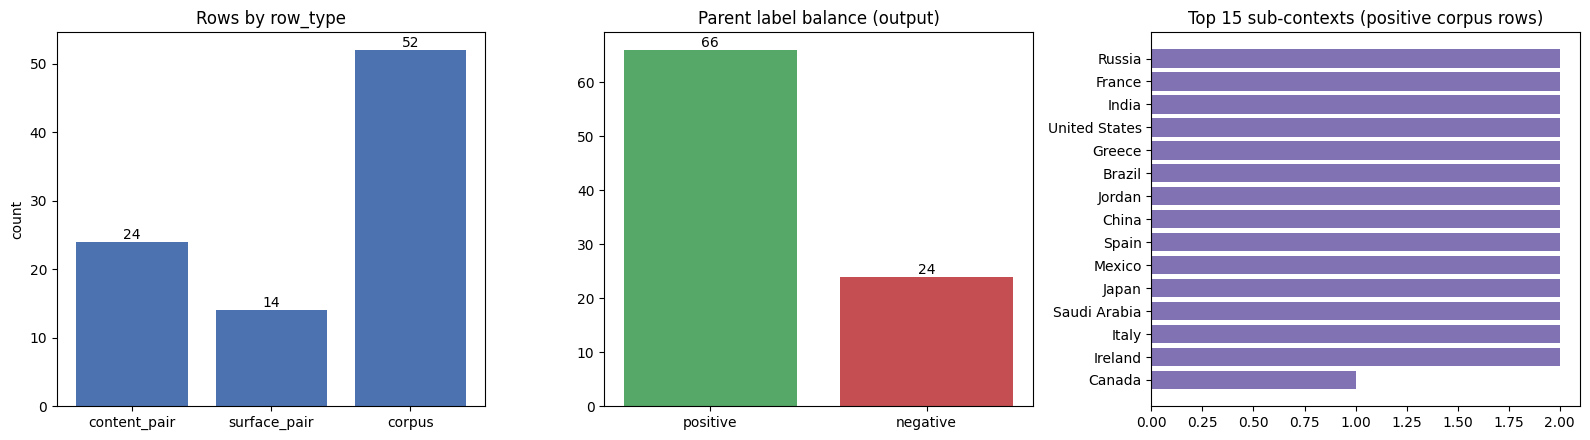


=== DEMO SUMMARY ===
dataset:                 taxonomic_absorption
total rows:              90
row types:               {'content_pair': 24, 'surface_pair': 14, 'corpus': 52}
distinct corpus subs:    26
homograph countries:     ['Georgia', 'Jordan', 'Turkey']
multi-word countries:    ['Costa Rica', 'New Zealand', 'Saudi Arabia', 'South Africa', 'United States']


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) rows by row_type
rt = Counter(df["row_type"])
axes[0].bar(list(rt.keys()), list(rt.values()), color="#4C72B0")
axes[0].set_title("Rows by row_type"); axes[0].set_ylabel("count")
for i, v in enumerate(rt.values()):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

# (2) parent-label balance
ob = Counter(df["output"])
axes[1].bar(list(ob.keys()), list(ob.values()), color=["#55A868", "#C44E52"])
axes[1].set_title("Parent label balance (output)")
for i, v in enumerate(ob.values()):
    axes[1].text(i, v, str(v), ha="center", va="bottom")

# (3) top sub-contexts by positive corpus rows
pos = df[(df.row_type == "corpus") & (df.output == "positive")]
top = Counter(pos["sub_context"]).most_common(TOP_K_SUBCONTEXTS)
labels = [t[0] for t in top]; vals = [t[1] for t in top]
axes[2].barh(range(len(labels)), vals, color="#8172B3")
axes[2].set_yticks(range(len(labels))); axes[2].set_yticklabels(labels)
axes[2].invert_yaxis()
axes[2].set_title(f"Top {TOP_K_SUBCONTEXTS} sub-contexts (positive corpus rows)")

plt.tight_layout(); plt.show()

# --- text summary ---
homographs = sorted(set(df["sub_context"].dropna()) & {"Georgia", "Turkey", "Chile", "Jordan"})
multi = sorted(set(df.loc[df["multi_token"] == True, "sub_context"].dropna()))
print("\n=== DEMO SUMMARY ===")
print(f"dataset:                 {data['datasets'][0]['dataset']}")
print(f"total rows:              {len(df)}")
print(f"row types:               {dict(Counter(df['row_type']))}")
print(f"distinct corpus subs:    {df[df.row_type=='corpus']['sub_context'].nunique()}")
print(f"homograph countries:     {homographs}")
print(f"multi-word countries:    {multi}")